# 06 — Logistic momentum vs momentum + volatility (rolling)

Same comparison as notebooks 03–05, now between two rolling models:

- **momentum + volatility** — the previous best: one momentum curve per volatility regime.
- **momentum logistic** — displays a walk-forward multi-feature logistic estimate of P(up), the same estimator the hidden-signal model keeps internal.

The idea: an attacker only wins if its model is richer than the displayed curve. The logistic
model shows a curve as rich as the predictive attacker's own model, so it should neutralise the
predictive attacker (no side is positive expected value) and shrink the regime-aware attacker
(volatility is just one of its features). The question is the cost on uninformed flow.

In [1]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())

In [2]:
from snapmarket.data import load_oracle_prices
from snapmarket.features import build_features
from snapmarket.parameters import SharedParameters
from snapmarket.models import build_model
from snapmarket.experiments import common_evaluation_start
from snapmarket.strategies import noise_pool
from snapmarket.engine import simulate

shared_parameters = SharedParameters()
features = build_features(load_oracle_prices(), shared_parameters)

models = {
    "momentum + volatility": build_model("momentum_volatility_rolling", features, shared_parameters),
    "momentum logistic": build_model("momentum_logistic_rolling", features, shared_parameters),
}
model_labels = list(models)
palette = ["#9ca3af", "#2563eb"]
color_map = {label: palette[index] for index, label in enumerate(model_labels)}

evaluation_start = common_evaluation_start(models.values())
print(f"common evaluation start: second {evaluation_start:,} (~{evaluation_start / 86_400:.0f} days in)")
for label, model in models.items():
    spread = model.display_probability[evaluation_start:]
    print(f"  {label}: displayed p_up range [{spread.min():.3f}, {spread.max():.3f}]")

common evaluation start: second 7,776,605 (~90 days in)
  momentum + volatility: displayed p_up range [0.386, 0.601]
  momentum logistic: displayed p_up range [0.020, 0.980]


## Part 1 — Uninformed random flow

Non-overlapping windows of a balanced noise pool through both models with the same seed, to
measure the cost of the richer displayed curve on the dominant uninformed flow.

In [3]:
import numpy as np
import pandas as pd

window_length = 200_000          # seconds per window
number_of_windows = 8            # raise for a longer evaluation

rows = []
for window_index in range(number_of_windows):
    start = evaluation_start + window_index * window_length
    if start + window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
        break
    seed = 1_000 + window_index
    for label, model in models.items():
        result = simulate(model, features, {"noise": noise_pool()}, start, window_length, seed=seed)
        rows.append({
            "window": window_index,
            "model": label,
            "house_edge": result.house_edge,
            "house_pnl": result.house_pnl,
            "volume": result.total_volume,
        })

results = pd.DataFrame(rows)
print(f"{results['window'].nunique()} windows of {window_length:,} seconds each")
results.pivot(index="window", columns="model", values="house_edge")[model_labels]

8 windows of 200,000 seconds each


model,momentum + volatility,momentum logistic
window,,
0,0.128844,0.126103
1,0.132288,0.129259
2,0.125964,0.117310
3,0.127983,0.123489
4,0.131050,0.128802
5,0.128831,0.126702
6,0.127519,0.120903
7,0.128206,0.125745


In [4]:
summary = (results
           .groupby("model")
           .agg(mean_house_edge=("house_edge", "mean"),
                std_house_edge=("house_edge", "std"),
                total_house_pnl=("house_pnl", "sum"),
                total_volume=("volume", "sum"))
           .reindex(model_labels))
summary["aggregate_house_edge"] = summary["total_house_pnl"] / summary["total_volume"]

print(summary.to_string(formatters={
    "mean_house_edge": "{:+.3%}".format,
    "std_house_edge": "{:.3%}".format,
    "total_house_pnl": "${:,.0f}".format,
    "total_volume": "${:,.0f}".format,
    "aggregate_house_edge": "{:+.3%}".format,
}))

                      mean_house_edge std_house_edge total_house_pnl total_volume aggregate_house_edge
model                                                                                                 
momentum + volatility        +12.884%         0.200%     $10,298,561  $79,937,696             +12.883%
momentum logistic            +12.479%         0.406%      $9,975,148  $79,937,696             +12.479%


Matplotlib is building the font cache; this may take a moment.


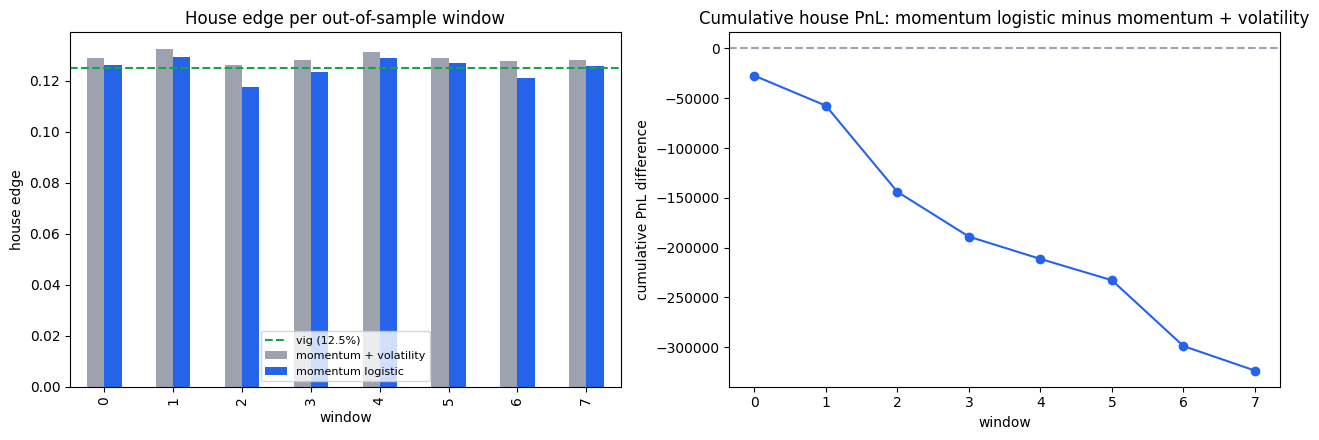

In [5]:
import matplotlib.pyplot as plt

edge_by_window = results.pivot(index="window", columns="model", values="house_edge")[model_labels]
house_pnl_by_window = results.pivot(index="window", columns="model", values="house_pnl")[model_labels]
pnl_difference = (house_pnl_by_window[model_labels[1]] - house_pnl_by_window[model_labels[0]]).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

edge_by_window.plot(kind="bar", ax=axes[0], color=color_map)
axes[0].axhline(shared_parameters.house_margin, ls="--", color="#16a34a",
                label=f"vig ({shared_parameters.house_margin:.1%})")
axes[0].set_title("House edge per out-of-sample window")
axes[0].set_xlabel("window"); axes[0].set_ylabel("house edge")
axes[0].legend(fontsize=8)

pnl_difference.plot(ax=axes[1], marker="o", color="#2563eb")
axes[1].axhline(0, ls="--", color="#9ca3af")
axes[1].set_title(f"Cumulative house PnL: {model_labels[1]} minus {model_labels[0]}")
axes[1].set_xlabel("window"); axes[1].set_ylabel("cumulative PnL difference")

plt.tight_layout(); plt.show()

## Part 2 — Informed attackers

The same three informed attackers, run inside a noise pool against each model. The displayed
logistic curve uses the same estimator as the predictive attacker, so that attacker should find
no positive-expected-value side; the regime-aware attacker should also shrink.

In [6]:
from snapmarket.data import load_fast_feed
from snapmarket.signals import walk_forward_logistic_probability, regime_conditional_probability
from snapmarket.strategies import predictive_bettor, lead_lag_bettor, regime_aware_bettor

fast_feed = load_fast_feed(expected_length=features.number_of_seconds)

logistic_probability = walk_forward_logistic_probability(features, shared_parameters)
regime_probability = regime_conditional_probability(features, shared_parameters)

informed_attackers = {
    "predictive (logistic)": predictive_bettor(logistic_probability),
    "lead-lag (fast feed)": lead_lag_bettor(features, fast_feed.log_price),
    "regime-aware": regime_aware_bettor(regime_probability),
}
print("informed attackers:", list(informed_attackers))

informed attackers: ['predictive (logistic)', 'lead-lag (fast feed)', 'regime-aware']


In [7]:
informed_window_length = 150_000
informed_number_of_windows = 6

attacker_rows = []
for model_label, model in models.items():
    for attacker_label, bettor in informed_attackers.items():
        attacker_pnl = attacker_stake = total_volume = 0.0
        for window_index in range(informed_number_of_windows):
            start = evaluation_start + window_index * informed_window_length
            if start + informed_window_length + shared_parameters.horizon_seconds >= features.number_of_seconds:
                break
            result = simulate(model, features,
                              {"pool": noise_pool(), "attacker": bettor},
                              start, informed_window_length, seed=200 + window_index)
            outcome = result.per_bettor["attacker"]
            attacker_pnl += outcome.pnl
            attacker_stake += outcome.stake
            total_volume += result.total_volume
        attacker_rows.append({
            "attacker": attacker_label,
            "model": model_label,
            "attacker_edge": attacker_pnl / attacker_stake if attacker_stake else 0.0,
            "volume_share": attacker_stake / total_volume if total_volume else 0.0,
        })

attacker_results = pd.DataFrame(attacker_rows)
attacker_edge = attacker_results.pivot(index="attacker", columns="model", values="attacker_edge")[model_labels]
attacker_edge

model,momentum + volatility,momentum logistic
attacker,,
lead-lag (fast feed),-0.171791,-0.171280
predictive (logistic),-0.040355,0.000000
regime-aware,0.029650,0.010116


In [8]:
print("Attacker edge (PnL / stake), positive = beats the house:\n")
print(attacker_edge.to_string(formatters={label: "{:+.2%}".format for label in model_labels}))

volume_share = attacker_results.pivot(index="attacker", columns="model", values="volume_share")[model_labels]
print("\nAttacker share of volume (0% means it found no bet worth taking):\n")
print(volume_share.to_string(formatters={label: "{:.1%}".format for label in model_labels}))

Attacker edge (PnL / stake), positive = beats the house:

model                 momentum + volatility momentum logistic
attacker                                                     
lead-lag (fast feed)                -17.18%           -17.13%
predictive (logistic)                -4.04%            +0.00%
regime-aware                         +2.97%            +1.01%

Attacker share of volume (0% means it found no bet worth taking):

model                 momentum + volatility momentum logistic
attacker                                                     
lead-lag (fast feed)                  50.0%             50.0%
predictive (logistic)                  5.5%              0.0%
regime-aware                           5.5%             11.6%


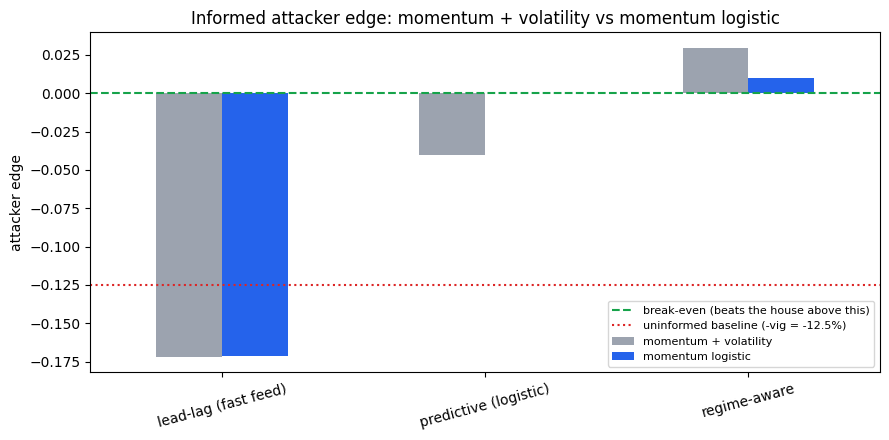

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
attacker_edge.plot(kind="bar", ax=ax, color=color_map)
ax.axhline(0, color="#16a34a", ls="--", label="break-even (beats the house above this)")
ax.axhline(-shared_parameters.house_margin, color="#dc2626", ls=":",
           label=f"uninformed baseline (-vig = {-shared_parameters.house_margin:.1%})")
ax.set_title("Informed attacker edge: momentum + volatility vs momentum logistic")
ax.set_ylabel("attacker edge"); ax.set_xlabel("")
ax.legend(fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()